# A02 Objective Variants

This notebook compares quality, consistency, and stability across objective variants.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

CSV_PATH = RESULTS_ROOT / "A02_objective_variants/A02_objective_variants.csv"
REQUIRED_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "objective_variant", "quality_metric", "quality_value",
    "consistency_metric", "consistency_value", "stability_metric", "stability_value", "split", "selection_rule",
    "run_id", "source_path", "notes",
]


def demo_objectives() -> pd.DataFrame:
    rows = [
        {"objective_variant": "no_aux", "quality_value": 0.1112, "consistency_value": 0.41, "stability_value": 0.67},
        {"objective_variant": "knn_only", "quality_value": 0.1146, "consistency_value": 0.53, "stability_value": 0.69},
        {"objective_variant": "z_only", "quality_value": 0.1138, "consistency_value": 0.46, "stability_value": 0.77},
        {"objective_variant": "balance_only", "quality_value": 0.1127, "consistency_value": 0.44, "stability_value": 0.73},
        {"objective_variant": "consistency_plus_z", "quality_value": 0.1170, "consistency_value": 0.58, "stability_value": 0.80},
        {"objective_variant": "full", "quality_value": 0.1185, "consistency_value": 0.61, "stability_value": 0.83},
    ]
    enriched = []
    for row in rows:
        enriched.append(
            {
                "paper_section": "A02_objective_variants",
                "panel": "objective",
                "dataset": "KuaiRec",
                "variant_or_model": "RouteRec",
                "objective_variant": row["objective_variant"],
                "quality_metric": "MRR@20",
                "quality_value": row["quality_value"],
                "consistency_metric": "consistency",
                "consistency_value": row["consistency_value"],
                "stability_metric": "stability",
                "stability_value": row["stability_value"],
                "split": "test",
                "selection_rule": "demo",
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            }
        )
    return pd.DataFrame(enriched)


In [2]:
df, mode = load_csv_or_demo(CSV_PATH, REQUIRED_COLUMNS, demo_builder=demo_objectives)
display(Markdown(f"**Load mode:** {mode}"))
display(df)


**Load mode:** demo

,paper_section,panel,dataset,variant_or_model,objective_variant,quality_metric,quality_value,consistency_metric,consistency_value,stability_metric,stability_value,split,selection_rule,run_id,source_path,notes
0,A02_objective_variants,objective,KuaiRec,RouteRec,no_aux,MRR@20,0.1112,consistency,0.41,stability,0.67,test,demo,demo,demo,demo data
1,A02_objective_variants,objective,KuaiRec,RouteRec,knn_only,MRR@20,0.1146,consistency,0.53,stability,0.69,test,demo,demo,demo,demo data
2,A02_objective_variants,objective,KuaiRec,RouteRec,z_only,MRR@20,0.1138,consistency,0.46,stability,0.77,test,demo,demo,demo,demo data
3,A02_objective_variants,objective,KuaiRec,RouteRec,balance_only,MRR@20,0.1127,consistency,0.44,stability,0.73,test,demo,demo,demo,demo data
4,A02_objective_variants,objective,KuaiRec,RouteRec,consistency_plus_z,MRR@20,0.1170,consistency,0.58,stability,0.80,test,demo,demo,demo,demo data
5,A02_objective_variants,objective,KuaiRec,RouteRec,full,MRR@20,0.1185,consistency,0.61,stability,0.83,test,demo,demo,demo,demo data


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/A02_objective_variants.png, /workspace/FeaturedMoE/writing/results/generated_figures/A02_objective_variants.pdf

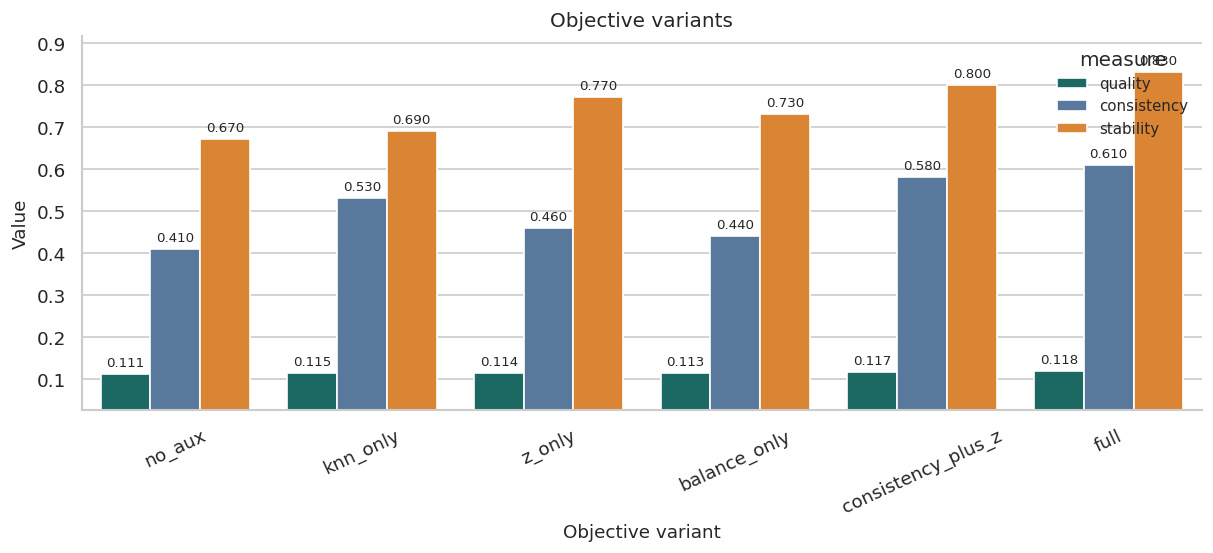

In [3]:
melted = pd.concat(
    [
        df[["objective_variant", "quality_value"]].rename(columns={"quality_value": "value"}).assign(measure="quality"),
        df[["objective_variant", "consistency_value"]].rename(columns={"consistency_value": "value"}).assign(measure="consistency"),
        df[["objective_variant", "stability_value"]].rename(columns={"stability_value": "value"}).assign(measure="stability"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
grouped_barplot(melted, x="objective_variant", hue="measure", y="value", ax=ax, title="Objective variants", ylabel="Value", xlabel="Objective variant", rotate=25)
saved_paths = export_figure(fig, "A02_objective_variants", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
